# QualityPhys - Camera Remote Vital Signs Estimator (CRVSE) Project

## Notebook P3-30: HR PhysNet R0 - v2's recipe on the ZBook training path

### What this notebook does
Retrains PhysNet once (seed 42) with exactly the recipe that produced the shipped `hr_physnet_v2` (NB_P3_18, config `baseline`), on the same training and validation subjects, but through the training path the next runs will use. It answers one question: **does this path reproduce v2?** Every later run - the corrected labels, VitalVideos added, VitalVideos alone, a fine-tune of v2 - changes one thing at a time from here, so this path has to be trusted first.

### Same as NB_P3_18
- PhysNet, identical layers; loss `neg_pearson + 0.05 x snr_loss`, each clip weighted by `cardiac_sqi`.
- Augmentation: speed resampling with probability 0.5 (factor drawn from 0.7-2.0; NB_P3_18 clamps any factor below 1.0 up to 1.0, so in practice only speed-ups happen - kept as it is), horizontal flip with probability 0.5.
- AdamW (lr 1e-3, weight decay 1e-4), cosine schedule over 30 epochs, batch 8, 2 clips per training recording per epoch, gradient clipping at 1.0.
- Training subjects: MCD 959, DLCN 609, UBFC-rPPG 35 recordings. Validation: MCD 232, DLCN 168, UBFC-rPPG 7, PhysDrive 68 (zero-shot), one centred clip each, scored as NB_P3_18 scored them.

### Different from NB_P3_18
- **The split is read, not recomputed.** `Data/phase3_split.csv` holds the assignment NB_P3_18 actually used (its shuffle ran over 785 subjects because PhysDrive was indexed for scoring); the index cell stops unless it reproduces NB_P3_18's counts.
- The local rechunked stores (`*_rc_none.h5`), named explicitly - no glob.
- Normalisation runs on the GPU: the loader hands over uint8 frames and the same per-clip, per-channel z-score is applied after the transfer. Checked against NB_P3_18's own dataset code on the same seed: identical clips, labels and HR targets; normalised frames within 0.003 (NumPy's float32 mean over several axes is the less exact of the two).
- bf16 autocast instead of fp16 with a gradient scaler.
- The loader runs in the main process (`NUM_WORKERS = 0`): Windows starts DataLoader workers by spawning, and a spawned worker cannot import a Dataset class defined in a notebook. Slower, not different.
- **The last epoch is kept.** NB_P3_18 kept its best epoch on the validation set; the best epoch is still logged here, for comparison only.

### Pass rule, fixed before the run
R0 reproduces v2 if its **last-epoch shared validation MAE** (MCD + DLCN + UBFC-rPPG, pooled as NB_P3_18 pooled it) lies **within 1.0 bpm of NB_P3_18's last epoch, 5.50**. A single seed moves this number by around half a bpm, so a gap beyond 1.0 bpm points at the path, not at chance. If R0 fails, nothing else is trained until the difference is explained.

### Outputs
Everything this run writes goes to one folder outside the repository, `D:\QualityPhys\phase 3 runs\R0_v2_recipe_seed42\`, created on the first run: the weights (`last_weights.pt`, `best_shared.pt`), the resume state (`last.pt`), `history.csv` (one row per epoch) and `summary.json`. The weights inherit CC BY-NC-SA and never go into git.

An interrupted run continues from its last finished epoch with `RESUME = True`. No face imagery is rendered anywhere in this notebook.

### Added after the run
Section 10 scores v2's shipped weights and R0's on the same validation clips at fp32, fp16 and bf16, without training, to separate what the MCD gap is made of. Its verdict sets the training precision of NB_P3_31.

## 1. Imports & config

In [1]:
import json
import random
import time
from collections import Counter
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


def find_repo_root(start):
    '''The first folder at or above `start` holding both app/ and Data/.'''
    for folder in [start, *start.parents]:
        if (folder / 'app').is_dir() and (folder / 'Data').is_dir():
            return folder
    raise FileNotFoundError(f'no repository root at or above {start}')


REPO_ROOT = find_repo_root(Path.cwd().resolve())
SPLIT_CSV = REPO_ROOT / 'Data' / 'phase3_split.csv'
STORE_DIR = Path(r'D:\QualityPhys\phase 3 datasets')
STORES = {'MCD': 'mcd_phase3_rc_none.h5', 'DLCN': 'dlcn_phase3_rc_none.h5',
          'UBFC-rPPG': 'ubfc_rppg_phase3_rc_none.h5', 'PhysDrive': 'physdrive_phase3_rc_none.h5'}

RUN_NAME = 'R0_v2_recipe_seed42'
RUN_DIR = Path(r'D:\QualityPhys\phase 3 runs') / RUN_NAME   # everything the run writes, outside the repo
RESUME = False   # True continues an interrupted run from its last finished epoch

# NB_P3_18's recipe, unchanged
TRAIN_DATASETS = ['MCD', 'DLCN', 'UBFC-rPPG']
EVAL_DATASETS = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']   # PhysDrive scored zero-shot, as in NB_P3_18
SHARED_DATASETS = {'MCD', 'DLCN', 'UBFC-rPPG'}             # the checkpoint metric of NB_P3_18
CLIP_LEN = 160
BATCH_SIZE = 8
CLIPS_PER_REC = 2
AUG_PROB = 0.5
SPEED_MIN, SPEED_MAX = 0.7, 2.0
SQI_CLAMP = 1e-3
LR = 1e-3
WEIGHT_DECAY = 1e-4
EPOCHS = 30
LAMBDA_SNR = 0.05
HR_LOW, HR_HIGH = 0.66, 3.0
SEED = 42

# The training path on this machine
NUM_WORKERS = 0              # see the header: notebook-defined Datasets cannot cross a spawn
AMP_DTYPE = torch.bfloat16

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
AMP = device.type == 'cuda'
torch.manual_seed(SEED); np.random.seed(SEED); random.seed(SEED)
torch.backends.cudnn.benchmark = True

print('repo:', REPO_ROOT)
print('torch', torch.__version__, '| device:', torch.cuda.get_device_name(0) if AMP else 'cpu',
      '| autocast:', AMP_DTYPE if AMP else 'off')
print('split file:', SPLIT_CSV.exists(), '| stores:',
      {k: (STORE_DIR / v).exists() for k, v in STORES.items()})

repo: D:\code\QualityPhys - CRVSE Project
torch 2.14.0+cu130 | device: NVIDIA RTX A5500 Laptop GPU | autocast: torch.bfloat16
split file: True | stores: {'MCD': True, 'DLCN': True, 'UBFC-rPPG': True, 'PhysDrive': True}


## 2. Index from the frozen split
The assignment comes from `Data/phase3_split.csv`; only the attributes the loader needs (`n_frames`, `fps`, `cardiac_sqi`) are read from the stores. The cell stops unless the counts are NB_P3_18's own and no subject sits on both sides.

In [2]:
EXPECTED_TRAIN = {'MCD': 959, 'DLCN': 609, 'UBFC-rPPG': 35}                    # NB_P3_18's training printout
EXPECTED_VAL = {'MCD': 232, 'DLCN': 168, 'UBFC-rPPG': 7, 'PhysDrive': 68}       # NB_P3_18's validation printout


def build_index(split_csv, store_dir, datasets, split):
    '''Records of one split side: the assignment from the split file, the attributes from the stores.'''
    table = pd.read_csv(split_csv, dtype=str, keep_default_na=False)
    rows = table[table['dataset'].isin(datasets) & (table['indexed'] == 'True') & (table['split'] == split)]
    index = []
    for name in datasets:
        path = store_dir / STORES[name]
        with h5py.File(path, 'r') as f:
            for r in rows[rows['dataset'] == name].itertuples():
                a = f[r.group].attrs
                index.append(dict(file=str(path), group=r.group, dataset=name, subject=r.subject,
                                  n_frames=int(a['n_frames']), fps=float(a.get('fps', 30.0)),
                                  sqi=float(a.get('cardiac_sqi', 0.0))))
    return index


train_index = build_index(SPLIT_CSV, STORE_DIR, TRAIN_DATASETS, 'train')
val_index = build_index(SPLIT_CSV, STORE_DIR, EVAL_DATASETS, 'val')
got_train = dict(sorted(Counter(r['dataset'] for r in train_index).items()))
got_val = dict(sorted(Counter(r['dataset'] for r in val_index).items()))
print('train recordings:', len(train_index), got_train)
print('val recordings:  ', len(val_index), got_val)

assert got_train == dict(sorted(EXPECTED_TRAIN.items())), f'training set differs from NB_P3_18: {got_train}'
assert got_val == dict(sorted(EXPECTED_VAL.items())), f'validation set differs from NB_P3_18: {got_val}'
both = {(r['dataset'], r['subject']) for r in train_index} & {(r['dataset'], r['subject']) for r in val_index}
assert not both, f'{len(both)} subject(s) on both sides, e.g. {sorted(both)[:3]}'
assert all(r['n_frames'] >= CLIP_LEN and r['sqi'] >= 0.05 for r in train_index + val_index)
print('index matches NB_P3_18; no subject on both sides')

train recordings: 1603 {'DLCN': 609, 'MCD': 959, 'UBFC-rPPG': 35}
val recordings:   475 {'DLCN': 168, 'MCD': 232, 'PhysDrive': 68, 'UBFC-rPPG': 7}
index matches NB_P3_18; no subject on both sides


## 3. Dataset & loader
NB_P3_18's sampler, line for line, except that it returns the frames as uint8: the per-clip, per-channel z-score happens in `to_model_input`, on the device.

In [3]:
def compute_hr(bvp, fps, low=HR_LOW, high=HR_HIGH):
    '''Cardiac-band spectral-peak HR (bpm) of a label clip, or nan.'''
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.size < 16 or not np.all(np.isfinite(x)) or np.std(x) < 1e-9:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(x.size))) ** 2
    fr = np.fft.rfftfreq(x.size, 1.0 / fps)
    b = (fr >= low) & (fr <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(fr[b][int(np.argmax(p[b]))] * 60.0)


class RPPGClipDataset(Dataset):
    '''Fixed-length clips with their frame-synced label; frames stay uint8 until they reach the device.'''

    def __init__(self, index, clip_len=CLIP_LEN, augment=False, clips_per_rec=1,
                 aug_prob=AUG_PROB, speed_range=(SPEED_MIN, SPEED_MAX), seed=SEED):
        self.index = index; self.clip_len = clip_len; self.augment = augment
        self.clips_per_rec = clips_per_rec; self.aug_prob = aug_prob; self.speed_range = speed_range
        self._files = {}; self._rng = np.random.default_rng(seed)

    def __getstate__(self):
        state = self.__dict__.copy()
        state['_files'] = {}          # open HDF5 handles cannot be pickled
        return state

    def _h5(self, path):
        h = self._files.get(path)
        if h is None:
            h = h5py.File(path, 'r'); self._files[path] = h
        return h

    def __len__(self):
        return len(self.index) * self.clips_per_rec

    def __getitem__(self, i):
        rec = self.index[i % len(self.index)]; g = self._h5(rec['file'])[rec['group']]
        n, T = rec['n_frames'], self.clip_len
        if self.augment and self._rng.random() < self.aug_prob:
            src_len = int(round(T * float(self._rng.uniform(*self.speed_range))))
            src_len = max(T, min(src_len, n))
        else:
            src_len = T
        max_start = n - src_len
        start = int(self._rng.integers(0, max_start + 1)) if (self.augment and max_start > 0) else max_start // 2
        frames_src = g['frames'][start:start + src_len]
        bvp_src = g['bvp'][start:start + src_len].astype(np.float32)
        pos = np.linspace(0, src_len - 1, T)
        frames = frames_src[np.rint(pos).astype(int)]
        bvp = np.interp(pos, np.arange(src_len), bvp_src)
        hr_bpm = compute_hr(bvp, rec['fps'])
        if self.augment and self._rng.random() < 0.5:
            frames = frames[:, :, ::-1, :]
        bvp = (bvp - bvp.mean()) / (bvp.std() + 1e-6)
        return dict(frames=torch.from_numpy(np.ascontiguousarray(frames)),      # uint8 [T,H,W,C]
                    bvp=torch.from_numpy(bvp.astype(np.float32)),
                    hr=torch.tensor(hr_bpm if np.isfinite(hr_bpm) else 0.0, dtype=torch.float32),
                    sqi=torch.tensor(rec['sqi'], dtype=torch.float32),
                    fps=torch.tensor(rec['fps'], dtype=torch.float32),
                    dataset=rec['dataset'])


def worker_init_fn(worker_id):
    info = torch.utils.data.get_worker_info(); ds = info.dataset
    ds._files = {}; ds._rng = np.random.default_rng(SEED + 1000 * (worker_id + 1) + int(info.seed % 100000))


def make_loader(index, augment, clips_per_rec=1):
    ds = RPPGClipDataset(index, augment=augment, clips_per_rec=clips_per_rec)
    kw = dict(batch_size=BATCH_SIZE, shuffle=augment, num_workers=NUM_WORKERS,
              pin_memory=device.type == 'cuda', drop_last=augment)
    if NUM_WORKERS > 0:
        kw.update(worker_init_fn=worker_init_fn, persistent_workers=True)
    return DataLoader(ds, **kw)


def to_model_input(frames_u8):
    '''[B,T,H,W,C] uint8 -> [B,C,T,H,W]: the per-clip, per-channel z-score over T, H and W that
    NB_P3_18 applied on the CPU, applied after the transfer.'''
    x = frames_u8.to(device, non_blocking=True).float()
    m = x.mean(dim=(1, 2, 3), keepdim=True)
    sd = x.std(dim=(1, 2, 3), keepdim=True, correction=0) + 1e-6
    return ((x - m) / sd).permute(0, 4, 1, 2, 3).contiguous()


probe = RPPGClipDataset(train_index[:1], augment=False)[0]
print('clip:', tuple(probe['frames'].shape), probe['frames'].dtype, '| bvp', tuple(probe['bvp'].shape),
      '| hr', round(float(probe['hr']), 1), '| fps', round(float(probe['fps']), 2), '| dataset', probe['dataset'])

clip: (160, 72, 72, 3) torch.uint8 | bvp (160,) | hr 82.2 | fps 31.33 | dataset MCD


## 4. Model - PhysNet (identical to NB_P3_18)

In [4]:
class PhysNet(nn.Module):
    '''PhysNet 3D-CNN encoder-decoder (Yu et al. 2019): [B,3,T,H,W] -> BVP [B,T].'''
    def __init__(self, frames=CLIP_LEN):
        super().__init__()
        self.frames = frames

        def block(cin, cout):
            return nn.Sequential(nn.Conv3d(cin, cout, (3, 3, 3), stride=1, padding=1),
                                 nn.BatchNorm3d(cout), nn.ReLU(inplace=True))

        self.b1 = nn.Sequential(nn.Conv3d(3, 16, (1, 5, 5), stride=1, padding=(0, 2, 2)),
                                nn.BatchNorm3d(16), nn.ReLU(inplace=True))
        self.b2 = block(16, 32); self.b3 = block(32, 64)
        self.b4 = block(64, 64); self.b5 = block(64, 64)
        self.b6 = block(64, 64); self.b7 = block(64, 64)
        self.b8 = block(64, 64); self.b9 = block(64, 64)
        self.up1 = nn.Sequential(nn.ConvTranspose3d(64, 64, (4, 1, 1), stride=(2, 1, 1), padding=(1, 0, 0)),
                                 nn.BatchNorm3d(64), nn.ELU(inplace=True))
        self.up2 = nn.Sequential(nn.ConvTranspose3d(64, 64, (4, 1, 1), stride=(2, 1, 1), padding=(1, 0, 0)),
                                 nn.BatchNorm3d(64), nn.ELU(inplace=True))
        self.poolspa = nn.AdaptiveAvgPool3d((frames, 1, 1))
        self.out = nn.Conv3d(64, 1, (1, 1, 1), stride=1, padding=0)
        self.maxpool_spa = nn.MaxPool3d((1, 2, 2))
        self.maxpool_spatem = nn.MaxPool3d((2, 2, 2))

    def forward(self, x):
        x = self.b1(x); x = self.maxpool_spa(x)
        x = self.b2(x); x = self.b3(x); x = self.maxpool_spatem(x)
        x = self.b4(x); x = self.b5(x); x = self.maxpool_spatem(x)
        x = self.b6(x); x = self.b7(x); x = self.maxpool_spa(x)
        x = self.b8(x); x = self.b9(x)
        x = self.up1(x); x = self.up2(x)
        x = self.poolspa(x); x = self.out(x)
        return x.view(x.shape[0], self.frames)


print('parameters:', sum(p.numel() for p in PhysNet().parameters()))   # 768,577 in v2

parameters: 768577


## 5. Losses & evaluation (identical to NB_P3_18)

In [5]:
def neg_pearson(pred, target):
    pred = pred - pred.mean(dim=1, keepdim=True)
    target = target - target.mean(dim=1, keepdim=True)
    num = (pred * target).sum(dim=1)
    den = torch.sqrt((pred ** 2).sum(dim=1) * (target ** 2).sum(dim=1) + 1e-8)
    return 1.0 - num / (den + 1e-8)


def snr_loss(pred, hr_bpm, fps, low=HR_LOW, high=HR_HIGH, delta_bpm=8.0):
    '''Negative in-band SNR (dB): power at the true fundamental (+first harmonic) vs the rest of the HR band. fp32.'''
    pred = pred.float(); pred = pred - pred.mean(dim=1, keepdim=True)
    B, T = pred.shape
    P = torch.abs(torch.fft.rfft(pred, dim=1)) ** 2
    Fn = P.shape[1]
    k = torch.arange(Fn, device=pred.device).float()
    freqs = k[None, :] * fps[:, None] / float(T)
    f0 = (hr_bpm / 60.0).clamp(min=low + 0.05, max=high - 0.05)[:, None]
    d = delta_bpm / 60.0
    band = (freqs >= low) & (freqs <= high)
    sig = (((freqs - f0).abs() <= d) | ((freqs - 2.0 * f0).abs() <= d)) & band
    noise = band & (~sig)
    sig_p = (P * sig).sum(dim=1) + 1e-8
    noise_p = (P * noise).sum(dim=1) + 1e-8
    return (-10.0 * torch.log10(sig_p / noise_p)).clamp(-30.0, 30.0)


def hr_from_bvp(bvp, fps, low=HR_LOW, high=HR_HIGH):
    x = np.asarray(bvp, dtype=np.float64); x = x - x.mean()
    if x.std() < 1e-8:
        return np.nan
    p = np.abs(np.fft.rfft(x * np.hanning(len(x)))) ** 2
    f = np.fft.rfftfreq(len(x), 1.0 / fps)
    b = (f >= low) & (f <= high)
    if not b.any() or p[b].sum() <= 0:
        return np.nan
    return float(f[b][int(np.argmax(p[b]))] * 60.0)


@torch.no_grad()
def evaluate(model, loader):
    '''Overall MAE, shared (MCD+DLCN+UBFC) MAE, per-dataset MAE and r, as NB_P3_18 computed them.'''
    model.eval(); rows = []
    for batch in loader:
        frames = to_model_input(batch['frames'])
        with torch.autocast(device.type, dtype=AMP_DTYPE, enabled=AMP):
            pred = model(frames)
        pred = pred.float().cpu().numpy()
        hr_true = batch['hr'].numpy(); fps = batch['fps'].numpy(); ds = batch['dataset']
        for i in range(len(pred)):
            if not (40.0 <= hr_true[i] <= 180.0):
                continue
            hp = hr_from_bvp(pred[i], float(fps[i]))
            if np.isfinite(hp):
                rows.append((ds[i], float(hr_true[i]), hp))
    df = pd.DataFrame(rows, columns=['dataset', 'hr_true', 'hr_pred'])
    if len(df) == 0:
        return dict(all=1e9, shared=1e9, per={}, r=float('nan'), n=0)
    df['ae'] = (df.hr_pred - df.hr_true).abs()
    per = {k: round(float(v), 3) for k, v in df.groupby('dataset')['ae'].mean().items()}
    shared = df[df.dataset.isin(SHARED_DATASETS)]['ae']
    return dict(all=float(df.ae.mean()),
                shared=float(shared.mean()) if len(shared) else float(df.ae.mean()),
                per=per, n=int(len(df)),
                r=float(np.corrcoef(df.hr_true, df.hr_pred)[0, 1]) if len(df) > 2 else float('nan'))

## 6. Trainer
NB_P3_18's loop with bf16 autocast (no gradient scaler needed). After every epoch it writes the history, the resume state and, when the shared MAE improves, a reference copy of those weights; the run's result is the last epoch.

In [6]:
def run_training():
    RUN_DIR.mkdir(parents=True, exist_ok=True)
    resume_path = RUN_DIR / 'last.pt'
    train_loader = make_loader(train_index, augment=True, clips_per_rec=CLIPS_PER_REC)
    val_loader = make_loader(val_index, augment=False, clips_per_rec=1)

    torch.manual_seed(SEED)
    model = PhysNet(frames=CLIP_LEN).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    history, start_epoch, best = [], 0, float('inf')
    if resume_path.exists():
        if not RESUME:
            raise RuntimeError(f'{resume_path} exists: set RESUME = True to continue that run, '
                               f'or change RUN_NAME to start a new one')
        state = torch.load(resume_path, map_location=device, weights_only=False)
        model.load_state_dict(state['model']); opt.load_state_dict(state['opt'])
        sched.load_state_dict(state['sched'])
        history, start_epoch, best = state['history'], state['epoch'] + 1, state['best']
        print(f'resuming after epoch {start_epoch} (best shared so far {best:.2f})')

    print(f'train: {len(train_loader.dataset)} clips per epoch, {len(train_loader)} steps | '
          f'val: {len(val_loader.dataset)} clips')
    for epoch in range(start_epoch, EPOCHS):
        model.train(); t0 = time.time(); losses = []
        for batch in train_loader:
            frames = to_model_input(batch['frames'])
            bvp = batch['bvp'].to(device, non_blocking=True)
            sqi = batch['sqi'].to(device, non_blocking=True)
            hr = batch['hr'].to(device, non_blocking=True)
            fps = batch['fps'].to(device, non_blocking=True)
            valid = ((hr >= 40) & (hr <= 180)).float()
            opt.zero_grad(set_to_none=True)
            with torch.autocast(device.type, dtype=AMP_DTYPE, enabled=AMP):
                pred = model(frames)
            pred = pred.float()
            per_loss = neg_pearson(pred, bvp) + LAMBDA_SNR * (snr_loss(pred, hr, fps) * valid)
            w = sqi.clamp(min=SQI_CLAMP)
            loss = (per_loss * w).sum() / w.sum()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            losses.append(loss.detach())
        sched.step()
        res = evaluate(model, val_loader)
        row = dict(epoch=epoch + 1, seconds=round(time.time() - t0, 1),
                   train_loss=round(float(torch.stack(losses).mean()), 4),
                   shared=round(res['shared'], 3), all=round(res['all'], 3), r=round(res['r'], 3),
                   **{f'mae_{k}': v for k, v in sorted(res['per'].items())})
        history.append(row)
        if res['shared'] < best:
            best = res['shared']
            torch.save(model.state_dict(), RUN_DIR / 'best_shared.pt')
        torch.save(dict(epoch=epoch, model=model.state_dict(), opt=opt.state_dict(),
                        sched=sched.state_dict(), history=history, best=best), resume_path)
        pd.DataFrame(history).to_csv(RUN_DIR / 'history.csv', index=False)
        left = (EPOCHS - epoch - 1) * row['seconds'] / 60
        print(f"  ep{epoch + 1}/{EPOCHS} | {row['seconds']:.0f}s | loss {row['train_loss']:.3f} | "
              f"shared {res['shared']:.2f} | all {res['all']:.2f} | {res['per']} | ~{left:.0f} min left",
              flush=True)
    torch.save(model.state_dict(), RUN_DIR / 'last_weights.pt')
    return pd.DataFrame(history)

## 7. Run R0 

In [7]:
t_start = time.time()
history = run_training()
print(f'done in {(time.time() - t_start) / 60:.1f} min')

train: 3206 clips per epoch, 400 steps | val: 475 clips
  ep1/30 | 74s | loss 1.421 | shared 23.99 | all 24.04 | {'DLCN': 21.228, 'MCD': 26.027, 'PhysDrive': 24.32, 'UBFC-rPPG': 22.714} | ~36 min left
  ep2/30 | 65s | loss 1.412 | shared 14.30 | all 14.93 | {'DLCN': 14.062, 'MCD': 14.583, 'PhysDrive': 18.695, 'UBFC-rPPG': 10.62} | ~30 min left
  ep3/30 | 64s | loss 1.043 | shared 13.69 | all 15.14 | {'DLCN': 7.299, 'MCD': 18.632, 'PhysDrive': 23.824, 'UBFC-rPPG': 3.118} | ~29 min left
  ep4/30 | 65s | loss 0.877 | shared 10.70 | all 13.08 | {'DLCN': 6.496, 'MCD': 13.976, 'PhysDrive': 27.298, 'UBFC-rPPG': 3.118} | ~28 min left
  ep5/30 | 65s | loss 0.835 | shared 8.99 | all 10.99 | {'DLCN': 5.558, 'MCD': 11.646, 'PhysDrive': 22.996, 'UBFC-rPPG': 3.118} | ~27 min left
  ep6/30 | 65s | loss 0.798 | shared 8.49 | all 11.04 | {'DLCN': 5.759, 'MCD': 10.634, 'PhysDrive': 26.305, 'UBFC-rPPG': 3.118} | ~26 min left
  ep7/30 | 65s | loss 0.780 | shared 8.54 | all 10.54 | {'DLCN': 4.621, 'MCD': 1

## 8. R0 against NB_P3_18
NB_P3_18's per-epoch validation log is copied below from its output. The verdict applies the pass rule from the header to R0's last epoch; the best epoch is shown beside it for comparison only.

                           R0  v2 (NB_P3_18)  R0 - v2
last epoch, MAE bpm                                  
shared (MCD+DLCN+UBFC)   6.45           5.50     0.95
MCD                      8.56           6.99     1.57
DLCN                     3.68           3.55     0.13
UBFC-rPPG                3.13           3.13     0.00
PhysDrive               34.58          28.62     5.96

best epoch (reference only): R0 5.65 at epoch 25, v2 5.22 at epoch 27

PASS: last-epoch shared MAE 6.45 is +0.95 bpm from v2 (rule: within 1.0)


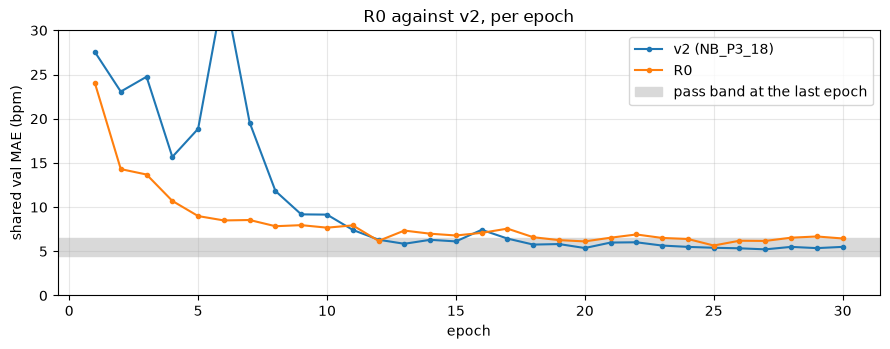

wrote D:\QualityPhys\phase 3 runs\R0_v2_recipe_seed42\summary.json


In [8]:
import matplotlib.pyplot as plt

V2_SHARED = [27.53, 23.07, 24.75, 15.68, 18.86, 34.72, 19.56, 11.82, 9.18, 9.15,
             7.42, 6.31, 5.85, 6.30, 6.12, 7.43, 6.44, 5.76, 5.82, 5.37,
             5.99, 6.02, 5.65, 5.50, 5.40, 5.34, 5.22, 5.50, 5.36, 5.50]
V2_LAST = {'shared': 5.50, 'MCD': 6.987, 'DLCN': 3.549, 'UBFC-rPPG': 3.134, 'PhysDrive': 28.621}
V2_BEST = {'epoch': 27, 'shared': 5.22}
PASS_TOLERANCE = 1.0

hist = pd.read_csv(RUN_DIR / 'history.csv')
complete = len(hist) == EPOCHS
last = hist.iloc[-1]
best_row = hist.loc[hist['shared'].idxmin()]

rows = [('shared (MCD+DLCN+UBFC)', float(last['shared']), V2_LAST['shared'])]
for name in ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']:
    col = f'mae_{name}'
    rows.append((name, float(last[col]) if col in hist else float('nan'), V2_LAST[name]))
table = pd.DataFrame(rows, columns=['last epoch, MAE bpm', 'R0', 'v2 (NB_P3_18)']).set_index('last epoch, MAE bpm')
table['R0 - v2'] = (table['R0'] - table['v2 (NB_P3_18)']).round(2)
print(table.round(2).to_string())
print(f"\nbest epoch (reference only): R0 {best_row['shared']:.2f} at epoch {int(best_row['epoch'])}, "
      f"v2 {V2_BEST['shared']:.2f} at epoch {V2_BEST['epoch']}")

gap = float(last['shared']) - V2_LAST['shared']
if not complete:
    verdict = f'incomplete: {len(hist)} of {EPOCHS} epochs - finish the run (RESUME = True) before judging'
elif abs(gap) <= PASS_TOLERANCE:
    verdict = f'PASS: last-epoch shared MAE {last["shared"]:.2f} is {gap:+.2f} bpm from v2 (rule: within {PASS_TOLERANCE})'
else:
    verdict = f'FAIL: last-epoch shared MAE {last["shared"]:.2f} is {gap:+.2f} bpm from v2 (rule: within {PASS_TOLERANCE})'
print('\n' + verdict)

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.plot(range(1, len(V2_SHARED) + 1), V2_SHARED, '-o', ms=3, label='v2 (NB_P3_18)')
ax.plot(hist['epoch'], hist['shared'], '-o', ms=3, label='R0')
ax.axhspan(V2_LAST['shared'] - PASS_TOLERANCE, V2_LAST['shared'] + PASS_TOLERANCE, color='0.85', zorder=0,
           label='pass band at the last epoch')
ax.set(xlabel='epoch', ylabel='shared val MAE (bpm)', ylim=(0, 30), title='R0 against v2, per epoch')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

summary = dict(run=RUN_NAME, notebook='NB_P3_30', recipe='NB_P3_18 baseline', seed=SEED,
               epochs_done=int(len(hist)), epochs=EPOCHS, amp=str(AMP_DTYPE) if AMP else 'off',
               num_workers=NUM_WORKERS, device=torch.cuda.get_device_name(0) if AMP else 'cpu',
               torch=torch.__version__, train=EXPECTED_TRAIN, val=EXPECTED_VAL,
               last_epoch={k: (round(float(v), 3) if isinstance(v, (int, float, np.floating, np.integer)) else v)
                           for k, v in last.items()},
               best_epoch=dict(epoch=int(best_row['epoch']), shared=round(float(best_row['shared']), 3)),
               v2=dict(last=V2_LAST, best=V2_BEST), pass_tolerance=PASS_TOLERANCE, verdict=verdict,
               minutes=round(float(hist['seconds'].sum()) / 60, 1))
with open(RUN_DIR / 'summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)
print('wrote', RUN_DIR / 'summary.json')

## 9. Findings

**R0 passes the pre-registered rule, with 0.05 bpm to spare.** Its last-epoch shared validation MAE is 6.45 bpm against v2's 5.50 (+0.95; the rule allowed 1.0). The path reproduces v2 on DLCN and UBFC-rPPG; the gap is MCD's.

| MAE, bpm | R0, last epoch | v2, last epoch | R0 - v2 | last 10 epochs, mean R0 / v2 |
|---|---|---|---|---|
| shared (407 clips) | 6.45 | 5.50 | +0.95 | 6.40 / 5.55 |
| MCD (232) | 8.56 | 6.99 | +1.57 | 8.52 / 7.18 |
| DLCN (168) | 3.68 | 3.55 | +0.13 | 3.60 / 3.38 |
| UBFC-rPPG (7) | 3.13 | 3.13 | 0.00 | 3.44 / 3.29 |
| PhysDrive (68, never trained on) | 34.58 | 28.62 | +5.96 | 32.59 / 27.53 |

- **MCD carries 0.89 of the 0.95 bpm.** A validation clip's HR is the peak of a 160-sample spectrum, so its error is a whole number of bins (11.25 bpm at 30 fps, 11.75 at MCD's 31.3). Counted in bins, DLCN differs by 2 over 168 clips (55 against 53), UBFC-rPPG not at all (2 and 2), MCD by 31 over 232 (169 against 138).
- **The gap is a level, not a last-epoch accident.** R0 sits above v2 in every epoch from 17 to 30, on the shared MAE and on MCD alike; its best epoch (25, 5.65) is 0.43 above v2's (27, 5.22).
- **Early training went the other way.** R0 fell without large swings and was under 8 bpm by epoch 8; v2 swung through epochs 3-7 (34.7 at epoch 6) and got under 8 only at epoch 11. NB_P3_18 logged no training loss, so the logs cannot say whether v2's lower late level is better optimisation or better generalisation.
- **A last-epoch number is a noisy draw.** In the final epochs the learning rate is near zero (2.7e-6 in epoch 30), yet the shared MAE still moves 0.1-0.2 bpm from one epoch to the next in both runs - most likely BatchNorm's running statistics, which the last few dozen batches set.
- **PhysDrive worsens as training proceeds in both runs** (R0 from 18.7 at epoch 2 to 34.6, v2 from 16.7 to 28.6): the closer the fit to the training corpora, the worse the reading of a driving scene. It stays a stress test and says nothing about the path.

**What one pair of runs cannot separate.** R0 and v2 start from the same initial weights but differ in three ways besides the plumbing: the random stream (NB_P3_18 drew clip offsets, speed factors and flips in two persistent DataLoader workers with their own generators, R0 in the main process - in effect another data seed); precision (bf16 against fp16, in training and in scoring); and the GPU, torch and cuDNN. The half-bpm seed spread behind the 1.0 tolerance was an estimate, never measured on either path. The run shows the path is sound - same index, same scoring code, DLCN and UBFC-rPPG within two bins at the last epoch - but not yet that it matches Kaggle on MCD.

**Scoring precision.** Both notebooks score validation under autocast (fp16 in NB_P3_18, bf16 here), while the app runs PhysNet in fp32 on the CPU, so neither validation number is at deployment precision.

**Speed.** 32.9 min for 30 epochs: 65 s per epoch with the loader in the main process, against ~400 s for NB_P3_18 on Kaggle. A Dataset module to bring workers back is not needed.

**Status.** Under the rule fixed before the run, the training path is accepted. What the MCD gap is made of - seed, precision or hardware - stays open; scoring v2's shipped weights and R0's on the same clips at fp32, fp16 and bf16, and two more R0 seeds, would separate most of it.

## 10. Paired scoring - what the MCD gap is made of
*Added after the run.* No training. v2's shipped weights (`Data/Phase3/phase_3_physnet_v2_baseline_best.zip`, NB_P3_18's epoch 27) and R0's best (epoch 25) and last (epoch 30) weights are scored on the same 475 validation clips, each at three precisions: **fp32 with TF32 off** - the arithmetic of the app, which runs PhysNet in fp32 on the CPU - **fp16 autocast** (how NB_P3_18 scored) and **bf16 autocast** (how section 7 scored). R0's last weights are scored once more after their BatchNorm statistics are re-estimated over one pass of the training clips, drawn and augmented as in training. Every clip's prediction is kept in `paired_scoring_clips.csv` and the summary in `paired_scoring.json`, both in the run folder.

In a fresh kernel, run sections 1-5 and then this section. Section 7 would refuse to start, because the run exists.

**Stated before it runs:**
- **Scoring check.** v2 at fp16 should reproduce NB_P3_18's epoch-27 line (shared 5.22; MCD 6.835, DLCN 3.08, UBFC-rPPG 3.134, PhysDrive 27.794) to within a few clips one bin apart, about 0.1 bpm on the shared MAE. At 0.3 bpm or more the data or the scoring differ from NB_P3_18, and nothing is trained until the difference is found.
- **Precision.** bf16 stays the training precision only if, for every model, it is about as faithful to fp32 as fp16 is: it changes the HR of at most 5 more clips than fp16 does, and it moves the shared MAE by at most 0.1 bpm. Otherwise NB_P3_31 trains in fp16 with a gradient scaler, as NB_P3_18 did, and runs seed 42 again so that the two precisions meet on an identical data stream.
- **BatchNorm.** Reported, not decided here: how far re-estimated statistics move R0's last epoch, against the 0.1-0.2 bpm it moved from epoch to epoch with the learning rate near zero. NB_P3_31 keeps both versions of every run.
- **Where MCD's gap lives.** Clip by clip, in spectrum bins: how many MCD clips each model gets exactly, one bin off, or further (harmonics and worse), and 95% bootstrap intervals for R0 - v2 with subjects resampled rather than clips - the 407 shared clips come from 144 subjects (MCD 2 recordings each, DLCN 8).

In [7]:
import copy
from contextlib import contextmanager

V2_WEIGHTS = REPO_ROOT / 'Data' / 'Phase3' / 'phase_3_physnet_v2_baseline_best.zip'   # NB_P3_18, epoch 27
V2_EPOCH27 = {'shared': 5.22, 'MCD': 6.835, 'DLCN': 3.08, 'UBFC-rPPG': 3.134, 'PhysDrive': 27.794}   # its fp16 printout
CORPORA = ['MCD', 'DLCN', 'UBFC-rPPG', 'PhysDrive']
MODES = ['fp32', 'fp16', 'bf16'] if device.type == 'cuda' else ['fp32']   # the autocast rows need the GPU


@contextmanager
def precision(mode):
    '''fp32 with TF32 off for convolutions and matmuls (the app's arithmetic), or fp16 / bf16 autocast.'''
    if mode == 'fp32':
        saved = torch.backends.cudnn.allow_tf32, torch.backends.cuda.matmul.allow_tf32
        torch.backends.cudnn.allow_tf32 = False
        torch.backends.cuda.matmul.allow_tf32 = False
        try:
            yield
        finally:
            torch.backends.cudnn.allow_tf32, torch.backends.cuda.matmul.allow_tf32 = saved
    else:
        with torch.autocast(device.type, dtype={'fp16': torch.float16, 'bf16': torch.bfloat16}[mode]):
            yield


def load_physnet(path):
    '''PhysNet with the weights at `path`, loaded strictly, in eval mode.'''
    model = PhysNet(frames=CLIP_LEN).to(device)
    model.load_state_dict(torch.load(path, map_location=device, weights_only=True))
    return model.eval()


def reestimate_bn(model, seed=SEED):
    '''A copy of `model` whose BatchNorm statistics are a plain average over one pass of the training clips,
    drawn and augmented as in training and computed in the training arithmetic; the weights are untouched.'''
    model = copy.deepcopy(model).eval()
    bns = [m for m in model.modules() if isinstance(m, nn.BatchNorm3d)]
    for m in bns:
        m.reset_running_stats()
        m.momentum = None            # a cumulative average: every batch weighs the same
        m.train()
    torch.manual_seed(seed)
    loader = make_loader(train_index, augment=True, clips_per_rec=CLIPS_PER_REC)
    with torch.no_grad():
        for batch in loader:
            with torch.autocast(device.type, dtype=AMP_DTYPE, enabled=AMP):
                model(to_model_input(batch['frames']))
    for m in bns:
        m.momentum = 0.1
    return model.eval()


hist = pd.read_csv(RUN_DIR / 'history.csv')
best_epoch = int(hist.loc[hist['shared'].idxmin(), 'epoch'])
last_epoch = int(hist['epoch'].iloc[-1])
t0 = time.time()
models = {'v2': load_physnet(V2_WEIGHTS),
          'R0 best': load_physnet(RUN_DIR / 'best_shared.pt'),
          'R0 last': load_physnet(RUN_DIR / 'last_weights.pt')}
models['R0 last, BN'] = reestimate_bn(models['R0 last'])
print(f'v2 = NB_P3_18 epoch 27 | R0 best = epoch {best_epoch} | R0 last = epoch {last_epoch} | '
      f'R0 last, BN = BatchNorm re-estimated over one training pass ({time.time() - t0:.0f} s)')
print('precisions:', MODES)

v2 = NB_P3_18 epoch 27 | R0 best = epoch 25 | R0 last = epoch 30 | R0 last, BN = BatchNorm re-estimated over one training pass (49 s)
precisions: ['fp32', 'fp16', 'bf16']


In [8]:
val_loader = make_loader(val_index, augment=False, clips_per_rec=1)   # unshuffled: clip k is val_index[k]
rows, k, t0 = [], 0, time.time()
with torch.no_grad():
    for batch in val_loader:
        x = to_model_input(batch['frames'])
        preds = {}
        for name, model in models.items():
            for mode in MODES:
                with precision(mode):
                    preds[name, mode] = model(x).float().cpu().numpy()
        hr_true, fps = batch['hr'].numpy(), batch['fps'].numpy()
        for i in range(len(hr_true)):
            rec = val_index[k]; k += 1
            assert rec['dataset'] == batch['dataset'][i], 'clips out of index order'
            for (name, mode), p in preds.items():
                rows.append(dict(dataset=rec['dataset'], subject=rec['subject'], group=rec['group'],
                                 model=name, precision=mode, hr_true=float(hr_true[i]),
                                 hr_pred=hr_from_bvp(p[i], float(fps[i])),
                                 bin_bpm=float(fps[i]) * 60.0 / CLIP_LEN))
assert k == len(val_index)
clips = pd.DataFrame(rows)
clips['scored'] = clips['hr_true'].between(40.0, 180.0) & np.isfinite(clips['hr_pred'])   # evaluate()'s rule
clips['ae'] = (clips['hr_pred'] - clips['hr_true']).abs()
clips['err_bins'] = (clips['ae'] / clips['bin_bpm']).round()
clips.to_csv(RUN_DIR / 'paired_scoring_clips.csv', index=False)
print(f'{k} clips x {len(models)} models x {len(MODES)} precisions in {time.time() - t0:.0f} s -> '
      f"{RUN_DIR / 'paired_scoring_clips.csv'}")

475 clips x 4 models x 3 precisions in 57 s -> D:\QualityPhys\phase 3 runs\R0_v2_recipe_seed42\paired_scoring_clips.csv


In [9]:
def summarise(df):
    '''Shared and per-corpus MAE over the scored clips, pooled as evaluate() pools them.'''
    s = df[df['scored']]
    out = {'shared': s.loc[s['dataset'].isin(SHARED_DATASETS), 'ae'].mean()}
    out.update({c: s.loc[s['dataset'] == c, 'ae'].mean() for c in CORPORA})
    out['n'] = len(s)
    return out


def paired_interval(name_a, name_b, corpora, n_boot=2000, seed=0):
    '''Mean of a's error minus b's over the clips both score in `corpora` (fp32), with a 95% interval
    from resampling subjects, not clips.'''
    fp = clips[clips['precision'] == 'fp32'].set_index(['dataset', 'subject', 'group'])
    a, b = fp[fp['model'] == name_a], fp[fp['model'] == name_b]
    d = (a['ae'] - b['ae'])[a['scored'] & b['scored']]
    d = d[d.index.get_level_values('dataset').isin(corpora)]
    g = d.groupby(level=['dataset', 'subject']).agg(['sum', 'count'])
    s, c = g['sum'].to_numpy(), g['count'].to_numpy()
    idx = np.random.default_rng(seed).integers(0, len(s), size=(n_boot, len(s)))
    lo, hi = np.percentile(s[idx].sum(axis=1) / c[idx].sum(axis=1), [2.5, 97.5])
    return dict(diff=float(d.mean()), lo=float(lo), hi=float(hi), clips=int(len(d)), subjects=int(len(s)))


order = [(name, mode) for name in models for mode in MODES]
table = pd.DataFrame([summarise(clips[(clips['model'] == n) & (clips['precision'] == m)]) for n, m in order],
                     index=pd.MultiIndex.from_tuples(order, names=['weights', 'precision']))
print('MAE, bpm (n = scored clips)\n' + table.round(3).to_string())
report = {}

# 1. Scoring check: v2 at fp16 against NB_P3_18's own printout
if 'fp16' in MODES:
    v2 = table.loc[('v2', 'fp16')]
    check = pd.DataFrame({'here, fp16': [v2[c] for c in V2_EPOCH27], 'NB_P3_18': list(V2_EPOCH27.values())},
                         index=list(V2_EPOCH27))
    check['difference'] = check['here, fp16'] - check['NB_P3_18']
    gap = float(check.loc['shared', 'difference'])
    verdict = ('reproduced' if abs(gap) <= 0.1 else
               'DIFFERENT: the data or the scoring differ from NB_P3_18 - train nothing until found' if abs(gap) >= 0.3
               else 'close but not reproduced: compare corpus by corpus before going on')
    print('\n1. Scoring check - v2 at fp16 against NB_P3_18, epoch 27\n' + check.round(3).to_string())
    print(f'   shared {gap:+.3f} bpm -> {verdict}')
    report['scoring_check'] = dict(shared_difference=round(gap, 3), verdict=verdict,
                                   per_corpus={c: round(float(v), 3) for c, v in check['difference'].items()})

# 2. Precision: what fp16 and bf16 change against fp32, on the same weights
if {'fp16', 'bf16'} <= set(MODES):
    pred = clips.set_index(['model', 'dataset', 'group', 'precision'])['hr_pred'].unstack('precision')
    rows = []
    for name in models:
        p = pred.loc[name]; row = {'weights': name}
        for mode in ('fp16', 'bf16'):
            same = (p[mode] == p['fp32']) | (p[mode].isna() & p['fp32'].isna())
            row[f'clips changed, {mode}'] = int((~same).sum())
            row[f'shared shift, {mode}'] = float(table.loc[(name, mode), 'shared'] - table.loc[(name, 'fp32'), 'shared'])
        rows.append(row)
    flips = pd.DataFrame(rows).set_index('weights')
    faithful = ((flips['clips changed, bf16'] - flips['clips changed, fp16'] <= 5)
                & (flips['shared shift, bf16'].abs() <= 0.1))
    verdict = ('bf16 stays: NB_P3_31 trains in bf16' if faithful.all() else
               'bf16 dropped: NB_P3_31 trains in fp16 with a gradient scaler and runs seed 42 again')
    print('\n2. Precision - against fp32 on the same weights (clips whose HR changes; shared MAE shift, bpm)')
    print(flips.round(3).to_string())
    print(f'   -> {verdict}')
    report['precision'] = dict(table=flips.round(3).reset_index().to_dict('records'), verdict=verdict)

# 3. BatchNorm re-estimated on R0's last weights
bn = (table.xs('R0 last, BN', level='weights') - table.xs('R0 last', level='weights')).drop(columns='n')
print('\n3. BatchNorm re-estimated - change in R0 last, bpm (negative = better)\n' + bn.round(3).to_string())
report['batchnorm_shift'] = {m: {c: round(float(v), 3) for c, v in r.items()} for m, r in bn.iterrows()}

# 4. Where MCD's gap lives: errors in spectrum bins, fp32
mcd = clips[(clips['precision'] == 'fp32') & clips['scored'] & (clips['dataset'] == 'MCD')]
structure = (mcd.assign(b=mcd['err_bins'].clip(upper=3).astype(int))
             .pivot_table(index='model', columns='b', values='group', aggfunc='count', fill_value=0)
             .reindex(index=list(models), columns=[0, 1, 2, 3], fill_value=0))
structure.columns = ['exact', '1 bin', '2 bins', '3+ bins']
structure['bins in total'] = mcd.groupby('model')['err_bins'].sum().reindex(list(models)).astype(int)
print('\n4. MCD clips by error, fp32 (one bin is about 11.7 bpm)\n' + structure.to_string())
v2_bins = mcd[mcd['model'] == 'v2'].set_index('group')['err_bins']
paired = {}
for name in ('R0 best', 'R0 last', 'R0 last, BN'):
    r0_bins = mcd[mcd['model'] == name].set_index('group')['err_bins']
    both = r0_bins.index.intersection(v2_bins.index)
    delta = r0_bins[both] - v2_bins[both]
    paired[name] = dict(worse=int((delta > 0).sum()), same=int((delta == 0).sum()), better=int((delta < 0).sum()))
print('   clip by clip against v2: ' + ' | '.join(f"{n}: worse {p['worse']}, same {p['same']}, better {p['better']}"
                                              for n, p in paired.items()))
report['mcd_structure'] = dict(counts=structure.reset_index().to_dict('records'), against_v2=paired)

# 5. R0 - v2 with subjects resampled
intervals = {}
for name in ('R0 best', 'R0 last', 'R0 last, BN'):
    for label, corpora in (('shared', SHARED_DATASETS), ('MCD', {'MCD'})):
        intervals[f'{name} - v2, {label}'] = paired_interval(name, 'v2', corpora)
iv = pd.DataFrame.from_dict(intervals, orient='index')
print('\n5. R0 - v2 in MAE (bpm, fp32), 95% intervals over subjects\n' + iv.round(3).to_string())
print('   v2 and R0 best were each picked as their run\'s best epoch on these same clips, so both read optimistic;'
      ' R0 last was not picked.')
report['intervals'] = {k: {kk: (round(vv, 3) if isinstance(vv, float) else vv) for kk, vv in v.items()}
                       for k, v in intervals.items()}

report['table'] = {f'{n} | {m}': {c: (round(float(v), 3) if c != 'n' else int(v)) for c, v in r.items()}
                   for (n, m), r in table.iterrows()}
report['models'] = {'v2': 'NB_P3_18 epoch 27 (shipped)', 'R0 best': f'epoch {best_epoch}',
                    'R0 last': f'epoch {last_epoch}', 'R0 last, BN': f'epoch {last_epoch}, BatchNorm re-estimated'}
report.update(precisions=MODES, device=torch.cuda.get_device_name(0) if device.type == 'cuda' else 'cpu',
              torch=torch.__version__)
with open(RUN_DIR / 'paired_scoring.json', 'w', encoding='utf-8') as f:
    json.dump(report, f, indent=2)
print('\nwrote', RUN_DIR / 'paired_scoring.json')

MAE, bpm (n = scored clips)
                       shared    MCD   DLCN  UBFC-rPPG  PhysDrive    n
weights     precision                                                 
v2          fp32        5.277  6.835  3.214      3.134     27.298  475
            fp16        5.249  6.835  3.147      3.134     27.298  475
            bf16        5.052  6.683  2.879      3.134     27.132  475
R0 best     fp32        5.828  7.899  3.080      3.134     28.952  475
            fp16        5.799  7.849  3.080      3.134     28.952  475
            bf16        5.654  7.545  3.147      3.134     29.614  475
R0 last     fp32        6.539  8.759  3.616      3.134     34.081  475
            fp16        6.481  8.657  3.616      3.134     33.750  475
            bf16        6.451  8.556  3.683      3.134     34.577  475
R0 last, BN fp32        6.338  8.405  3.616      3.134     33.088  475
            fp16        6.338  8.405  3.616      3.134     33.088  475
            bf16        6.539  8.759  3.616      

### Findings of section 10

**The data and the scoring are NB_P3_18's.** v2's shipped weights scored at fp16 give a shared MAE of 5.249 against NB_P3_18's 5.22 (+0.03): MCD and UBFC-rPPG identical, DLCN one clip one bin apart, PhysDrive (outside the shared metric) three bins over 68 clips - its clips are the most fragile to arithmetic, below. R0's weights at bf16 reproduce section 7's own log exactly (epoch 30: 6.451; epoch 25: 5.654). Whatever separates R0 from v2 happened in training.

**Precision tips a few fragile clips; it does not move the level.** On the same weights, fp16 changes the HR of 0-3 of the 475 clips against fp32 and bf16 changes 6-8. The changes are jumps of 1-7 bins in either direction, on clips whose spectrum holds two peaks of nearly equal power - MCD and PhysDrive mostly - and the shared MAE moves by -0.23 to +0.20 bpm under bf16, with no consistent sign. Under the rule stated before the run, bf16 is dropped (v2 changes 7 more clips under bf16 than under fp16 and moves 0.23 bpm; R0's best moves 0.17, the BatchNorm copy 0.20): NB_P3_31 trains in fp16 with a gradient scaler, as NB_P3_18 did, and runs seed 42 again.

| shared MAE, bpm | fp32 | fp16 | bf16 |
|---|---|---|---|
| v2, epoch 27 (shipped) | 5.28 | 5.25 | 5.05 |
| R0 best, epoch 25 | 5.83 | 5.80 | 5.65 |
| R0 last, epoch 30 | 6.54 | 6.48 | 6.45 |
| R0 last, BatchNorm re-estimated | 6.34 | 6.34 | 6.54 |

**R0's 0.05 bpm margin is smaller than what bf16 scoring added.** At fp32 - the app's arithmetic - R0's last epoch reads 6.54, not 6.45, about 1.0 above NB_P3_18's last epoch. Those weights were not kept, so 5.50 exists only at fp16; v2's best epoch moved +0.03 from fp16 to fp32. At the app's precision R0 sits on the edge of the tolerance. Section 8's verdict stands as pre-registered, but it says less than its PASS suggests.

**BatchNorm re-estimation is worth about the end-of-training wobble.** It moves R0's last epoch by -0.20 bpm at fp32 (MCD -0.35, DLCN 0, PhysDrive -0.99) and -0.14 at fp16, but +0.09 at bf16 - the 0.1-0.2 bpm the run moved from epoch to epoch with the learning rate near zero, and the size of bf16's own noise. It leaves the gap where it was: re-estimated, R0 still has 166 bins of MCD error against v2's 135.

**R0's MCD gap is over-reading.** At fp32, R0's last epoch gets 131 MCD clips exact against v2's 144; one-bin errors are as common (69 against 72), errors of two bins or more twice as common (32 against 16). Signed, R0 reads high: 2-3 bins too high on 17 clips against v2's 3, and on the 150 MCD clips labelled 76-100 bpm its mean error is +3.1 bpm against v2's +0.5. Of the 21 clips that R0 misses by two bins or more while v2 lands within one, 14 are labelled 70-94 bpm and read by R0 at 105-130. Clip by clip, R0's last epoch is worse than v2 on 37 MCD clips, better on 18 and the same on 177. The errors belong to the run, not to one epoch: of the 32 clips R0's last epoch misses by two bins or more, its best epoch misses 25 as well, v2 11.

**This validation set cannot resolve the gap at the subject level.** With subjects resampled (144 shared, 116 MCD), R0's best epoch against v2's best is +0.55 bpm shared (95% interval -0.39 to 1.54) and +1.06 on MCD (-0.46 to 2.58). R0's last epoch against v2's best is +1.26 (0.15 to 2.33), but v2's weights were picked as its best epoch on these same clips, so that interval leans against R0. One centred clip per recording resolves about +/-1 bpm between two models on the shared MAE - a limit to keep in mind when R, A, B and C are compared on it.

**What remains open.** A training effect, concentrated in R0 over-reading mid-range MCD clips: about half a bpm best against best, within what 144 subjects resolve. Seed, training precision and hardware are still not separated. NB_P3_31's fp16 runs separate the first two: seed 42 at fp16 meets NB_P3_30's bf16 run on an identical data stream, and three fp16 seeds give the spread.